In [70]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
import numpy as np


In [71]:
michae_emo = 'Michael - Emotion (5 neutral) '
mel_emo = 'Melanie - Emotion (5 neutral)'
df = pd.read_csv('YearDataDailyCollector.csv')
print(df.columns)
df
# convert the date column to datetime
df['Date'] = pd.to_datetime(df['Timestamp'])
df[['Timestamp','Date']]
# if the time is from before 6am, then it is the previous day
df['Date'] = df['Date'] - pd.Timedelta(hours=6)
# create a "thedate" that is just the date and strip off the time


Index(['Timestamp', 'Loud laughter', 'Cried', 'Tender moments', 'Fought',
       'Did you read a book today?',
       'What books did you finish reading? (leave blank for none)',
       'Did you watch TV today?',
       'What shows/movies did you finish reading? (leave blank for none)',
       'Michael - Emotion (5 neutral) ', 'Melanie - Emotion (5 neutral)',
       'Did dishes?', 'Miles of Cardio',
       'Did you run non-work errands on your bicycle?',
       'Did strength training?', 'Went climbing?', 'Spent time with family?',
       'Poops', 'Cups of coffee', 'Did you both consume fruit today?',
       'Did you both consume vegetables today?',
       'Travel to work (select all that apply)', 'Worst part of the day',
       'Best part of the day', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')


In [72]:
print(df['Date'].dt.strftime('%m-%d-%Y')[0])
print(dates[0].strftime('%m-%d-%Y'))

01-01-2024
01-01-2024


In [122]:
def create_activity_pie_grid(df):
    """
    Create a grid of pie charts showing the distribution of various activities
    
    Args:
        df: DataFrame containing the activity columns
    """
    # List of columns to analyze
    columns = [
        # Emotional/Relationship moments
        'Did we laugh?',            # Loud laughter
        'Did we cry?',                     # Cried
        'Did we have a tender moment?',     # Tender moments
        'Did we fight?',                   # Fought
        'Did we spend time with family?',  # Spent time with family
        
        # Health and Exercise
        'Did we do cardio?',               # Miles of Cardio
        'Did we go climbing?',             # Went climbing
        'Did we do strength training?',    # Did strength training
        
        # Food and Nutrition
        'Did we eat fruit?',               # Did you both consume fruit today
        'Did we eat vegetables?',          # Did you both consume vegetables today
        
        # Daily Activities
        'Did we watch TV?',                # Did you watch TV today
        'Did we read?',                    # Did you read a book today
        'Did we do dishes?'                # Did dishes
    ]
    
    # Define colors
    color_map = {
        'Yes': '#287521',    # Green
        'No': '#DF0001',     # Red
        'Other1': '#1f77b4', # Blue
        'Other2': '#ff7f0e', # Orange
        'Other3': '#9467bd', # Purple
        'Other4': '#e377c2'  # Pink
    }
    
    n_cols = 7
    n_rows = 2
    
    # Create figure
    fig = plt.figure(figsize=(15, 4))  # Reduced height to decrease vertical spacing
    plt.style.use('seaborn')
    
    # Create pie charts
    for idx, col in enumerate(columns):
        df[col] = df[col].replace({'0': 'No', '1': 'Yes', '3':'Yes','2':'Yes','9':'Yes','4':'Yes'})
        ax = plt.subplot(n_rows, n_cols, idx + 1)
        
        # Count values
        value_counts = df[col].value_counts()
        
        # Calculate percentages
        total = value_counts.sum()
        percentages = value_counts / total * 100
        
        # Create labels with percentages
        labels = [f'{idx}: {val:.1f}%' for idx, val in percentages.items()]
        
        # Determine colors for this pie chart
        colors = []
        for category in value_counts.index:
            if category in color_map:
                colors.append(color_map[category])
            else:
                # For any additional categories, use the other colors in sequence
                # For any additional categories, use the other colors in sequence
                extra_colors = [color_map['Other1'], color_map['Other2'], 
                                color_map['Other3'], color_map['Other4']]
                colors.append(extra_colors[len(colors) % 4])  # Changed from % 3 to % 4
        
        # Create pie chart
        wedges, texts, autotexts = ax.pie(
            percentages,
            labels=labels,
            autopct='',  # We already included percentages in labels
            colors=colors,
            textprops={'fontsize': 8}
        )
        
        # Add title
        ax.set_title(col, fontsize=10, pad=5)  # Reduced pad to decrease spacing
    
    # Adjust layout with tighter spacing
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.2)  # Reduced spacing between plots
    
    return fig

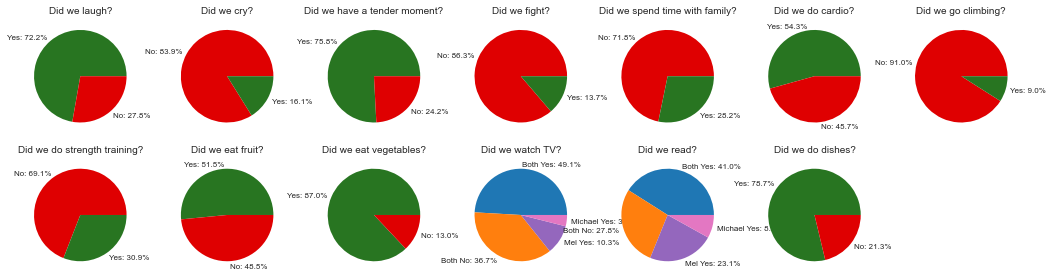

In [123]:
# Load data
df = pd.read_csv('YearDataDailyCollector.csv')
df['Miles of Cardio'] = np.where(df['Miles of Cardio'] == 0, 'No', 'Yes')
# rename colunmns:

column_mapping = {
    'Loud laughter': 'Did we laugh?',
    'Cried': 'Did we cry?',
    'Tender moments': 'Did we have a tender moment?',
    'Fought': 'Did we fight?',
    'Spent time with family?': 'Did we spend time with family?',
    'Miles of Cardio': 'Did we do cardio?',
    'Went climbing?': 'Did we go climbing?',
    'Did strength training?': 'Did we do strength training?',
    'Did you both consume fruit today?': 'Did we eat fruit?',
    'Did you both consume vegetables today?': 'Did we eat vegetables?',
    'Did you watch TV today?': 'Did we watch TV?',
    'Did you read a book today?': 'Did we read?',
    'Did dishes?': 'Did we do dishes?'
}

# Rename the columns
df = df.rename(columns=column_mapping)
# Create visualization
fig = create_activity_pie_grid(df)

# Save plot
plt.savefig('activity_pies.png', dpi=300, bbox_inches='tight')

In [39]:
columns = [
        'Loud laughter', 'Cried', 'Tender moments', 'Fought',
        'Did you read a book today?', 'Did you watch TV today?',
        'Did dishes?', 'Did strength training?', 'Went climbing?',
        'Spent time with family?', 'Did you both consume fruit today?', 
        'Did you both consume vegetables today?', 'Miles of Cardio'
    ]
len(columns)

13

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

def create_task_timeline(df):
    """
    Create a timeline visualization of binary task completion data.
    
    Parameters:
    df (pandas.DataFrame): DataFrame with a Timestamp column and binary task columns
    """
    # List of task columns to plot
    columns = [
        # Emotional/Relationship moments
        'Did we laugh?',            # Loud laughter
        'Did we cry?',                     # Cried
        'Did we have a tender moment?',     # Tender moments
        'Did we fight?',                   # Fought
        'Did we spend time with family?',  # Spent time with family
        
        # Health and Exercise
        'Did we do cardio?',               # Miles of Cardio
        'Did we go climbing?',             # Went climbing
        'Did we do strength training?',    # Did strength training
        
        # Food and Nutrition
        'Did we eat fruit?',               # Did you both consume fruit today
        'Did we eat vegetables?',          # Did you both consume vegetables today
        
        # Daily Activities
        'Did we watch TV?',                # Did you watch TV today
        'Did we read?',                    # Did you read a book today
        'Did we do dishes?'                # Did dishes
    ]
    
    # invert the list
    columns = columns[::-1]

    # Set up the plot style
    # plt.style.use('seaborn')
    
    # Create figure and axis with appropriate size
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Generate a color palette
    colors = sns.color_palette('husl', n_colors=len(columns))
    
    # Plot each task
    for idx, (task, color) in enumerate(zip(columns, colors)):
        # Get dates where task was completed
        # if task is reading or TV replace "Both No" with "No", "Both Yes" with "Yes", "Mel Yes" with "Yes", "Michael Yes" with "Yes"
        df[task] = df[task].replace({'Both No': 'No', 'Both Yes': 'Yes', 'Mel Yes':'Yes', 'Michael Yes':'Yes'})
        
        mask = df[task] == 'Yes'
        completion_dates = df.loc[mask, 'Date']
        
        if len(completion_dates) > 0:
            # Plot points for each completion
            ax.scatter(completion_dates, 
                      [idx] * len(completion_dates),
                      color=color,
                      label=task,
                      s=25,
                      marker='s',
                      alpha=1)
            
            # Draw short horizontal lines at each point
            for date in completion_dates:
                ax.hlines(y=idx,
                         xmin=date - pd.Timedelta(days=0.25),
                         xmax=date + pd.Timedelta(days=0.25),
                         color=color,
                         linewidth=1)
    
    # Customize the plot
    ax.set_ylim(-1, len(columns))
    ax.set_yticks(range(len(columns)))
    ax.set_yticklabels(columns)
    
    # Format x-axis
    # ax.set_xlabel('Date')
    plt.xticks(rotation=45)
    # add vertical grey lines for each week
    start_date = df['Date'].min()
    end_date = df['Date'].max()
    date_range = pd.date_range(start_date, end_date, freq='W')
    for date in date_range:
        ax.axvline(date, color='grey', linestyle='--', linewidth=0.8)
        
    # Remove y-axis label as it's redundant
    ax.set_ylabel('')
    
    # Add black grid for better readability but remove white background
    ax.grid(True, axis='x', color='black')
    # ax.grid(True, axis='y', color='black')
    ax.set_facecolor('white')
    
    
    # Add title
    plt.title('Melanie & Michael\'s Year of Daily Data', pad=20, fontsize=32)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig, ax


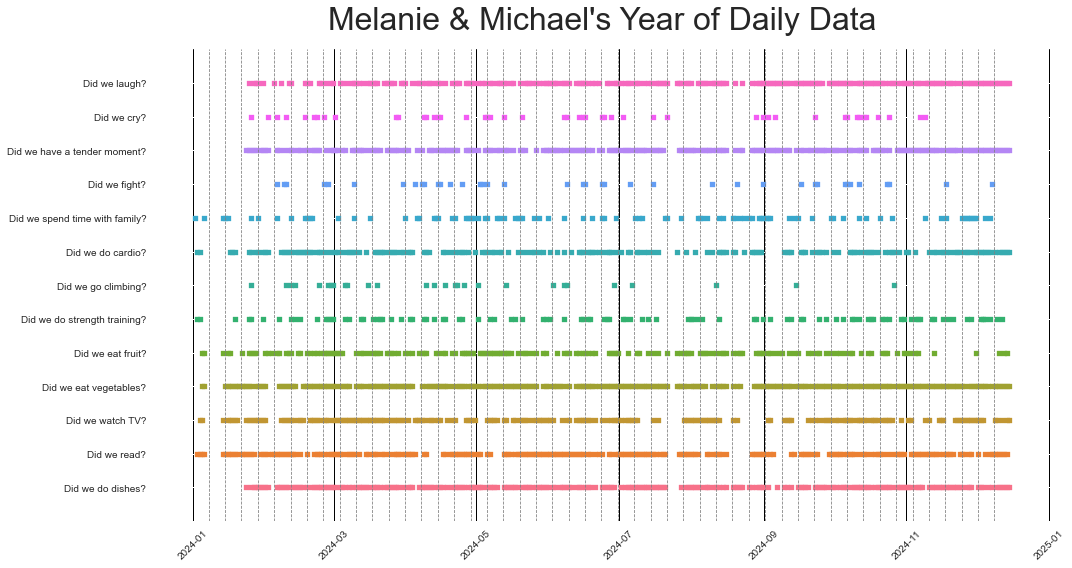

In [117]:
df = pd.read_csv('YearDataDailyCollector.csv')
df['Miles of Cardio'] = np.where(df['Miles of Cardio'] == 0, 'No', 'Yes')
# rename colunmns:

column_mapping = {
    'Loud laughter': 'Did we laugh?',
    'Cried': 'Did we cry?',
    'Tender moments': 'Did we have a tender moment?',
    'Fought': 'Did we fight?',
    'Spent time with family?': 'Did we spend time with family?',
    'Miles of Cardio': 'Did we do cardio?',
    'Went climbing?': 'Did we go climbing?',
    'Did strength training?': 'Did we do strength training?',
    'Did you both consume fruit today?': 'Did we eat fruit?',
    'Did you both consume vegetables today?': 'Did we eat vegetables?',
    'Did you watch TV today?': 'Did we watch TV?',
    'Did you read a book today?': 'Did we read?',
    'Did dishes?': 'Did we do dishes?'
}

for col in df.columns:
    if col not in column_mapping:
        column_mapping[col] = col
df = df.rename(columns=column_mapping)

df['Date'] = pd.to_datetime(df['Timestamp'])
# if the time is from before 6am, then it is the previous day
df['Date'] = df['Date'] - pd.Timedelta(hours=6)

fig, ax = create_task_timeline(df)
# save fig
plt.savefig('task_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

